# https://scib-metrics.readthedocs.io/en/latest/notebooks/lung_example.html

In [18]:

import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import scanpy as sc
import anndata

import numpy as np
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

import scbiot as scb
from scbiot.utils import set_seed

warnings.filterwarnings("ignore")
set_seed(42)

dir = Path.cwd()
print(dir)
print(dir.parent)
verbose = True


Random seed set as 42
/home/figo/software/python_libs/scbiot/examples
/home/figo/software/python_libs/scbiot


In [19]:
adata_gex_path = f'{dir}/inputs/Yao-2021-RNA.h5ad'
adata_atac_path = f'{dir}/inputs/Yao-2021-ATAC.h5ad'

adata_gex = sc.read(
    adata_gex_path,
    backup_url="https://figshare.com/ndownloader/files/59742656",
)

adata_atac = sc.read(
    adata_atac_path,
    backup_url="https://figshare.com/ndownloader/files/59742647",
)


In [ ]:

# 0) ATAC preprocessing (peak filtering -> LSI -> GA + smoothing)
# figshare link: https://figshare.com/ndownloader/files/59742641
gtf_file = f"{dir}/inputs/gencode.vM25.chr_patch_hapl_scaff.annotation.gtf.gz"

adata_ga = scb.pp.create_gene_activity(adata_atac, adata_gex, gtf_file=gtf_file, verbose=True)


Removed 19,172 promoter-proximal peaks (2000bp upstream / 500bp downstream). Remaining: 129,642
Running Iterative LSI iteration 1 ...
Running Iterative LSI iteration 2 ...
[GA] Kept 22,358/56,262 genes by biotype ['protein_coding', 'lncRNA']
[GA] Peaks contigs: 21; Genes contigs: 108; Common: 21
[GA] Using gene field: gene_name
[GA] Built GA with shape (54844, 15547) (cells × genes) from 148,814 peaks.


In [ ]:
adata_ga.var_names[:10]

Index(['-1', '0610010F05Rik', '0610010K14Rik', '0610012G03Rik',
       '0610030E20Rik', '0610040J01Rik', '1110002E22Rik', '1110004F10Rik',
       '1110008P14Rik', '1110012L19Rik'],
      dtype='object')

In [ ]:
adata_gex

AnnData object with n_obs × n_vars = 69727 × 27123
    obs: 'x', 'cluster_label', 'subclass_label', 'class_label', 'cluster_color', 'size', 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'domain', 'protocol', 'dataset', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'chrom', 'chromStart', 'chromEnd', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts', 'gene_type', 'gene_name', 'mgi_id', 'havana_gene', 'tag', 'n_counts', 'highly_variable', 'highly_variable_

In [ ]:
# adata_ga.X = adata_ga.layers['ga_smooth']

In [ ]:
adata_gex.obs["cell_type"] = adata_gex.obs["cell_type"]
adata_ga.obs["cell_type"] = "Unknown"

adata_gex.obs['batch'] = adata_gex.obs['library_id']
adata_ga.obs['batch'] = adata_ga.obs['batch']

adata = anndata.concat([adata_gex, adata_ga], join='inner', label="modality", keys=["reference", "query"])
print(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="seurat_v3", batch_key='batch')
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.scale(adata)
sc.tl.pca(adata, n_comps=50, use_highly_variable=True)


adata, metrics = scb.ot.integrate(
    adata,
    modality='anchor',
    obsm_key="X_pca", 
    batch_key="batch",   
    out_key="X_supbiot",    
    label_key="cell_type",
    unlabeled_category="Unknown"    
)


AnnData object with n_obs × n_vars = 124571 × 15185
    obs: 'domain', 'protocol', 'dataset', 'cell_type', 'batch', 'modality'
[prealign] CORAL enabled target=auto strength=1.0
[baseline] KNN backend=FAISS-GPU mix=2.1570 strain=0.00000
[iter 01] mix=2.176 overlap0=0.766 strain=0.00915 floor~0.600 J=0.058 best_it=1
[iter 02] mix=2.175 overlap0=0.649 strain=0.02763 floor~0.607 J=0.067 best_it=2
[iter 03] mix=2.169 overlap0=0.568 strain=0.04895 floor~0.614 J=0.037 best_it=2
[iter 04] mix=2.169 overlap0=0.573 strain=0.04912 floor~0.621 J=0.039 best_it=2
[iter 05] mix=2.169 overlap0=0.585 strain=0.04957 floor~0.629 J=0.048 best_it=2
[early stop] plateau reached.
[final] it*=2 mix=2.175 overlap0=0.649 strain=0.02763 tw=0.991


In [ ]:
adata = scb.ot.supbiot(
adata,
label_key="cell_type",
unlabeled_category="Unknown",
pred_label_key='pred_cell_type',
pred_conf_key="pred_confidence",
min_conf=0.25
)


In [ ]:
adata_ga = adata[adata.obs['modality'] == 'query'].copy()
adata_gex = adata[adata.obs['modality'] == 'reference'].copy()
adata_ga.obs['pred_cell_type'].value_counts()

pred_cell_type
L4/5 IT    26593
L6 CT      10473
L2/3 IT     8887
L6 IT       2798
Vip         1409
Sst         1218
Lamp5       1081
NP           963
Pvalb        735
L5 ET        607
Sncg          80
Name: count, dtype: int64

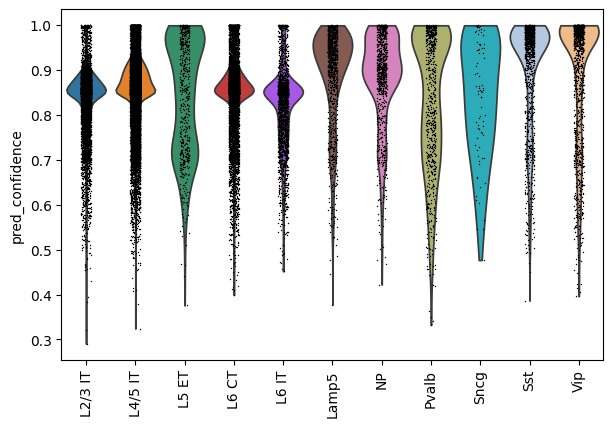

In [ ]:
sc.pl.violin(adata_ga, keys="pred_confidence", groupby="pred_cell_type", rotation=90)

In [ ]:
sc.pp.neighbors(adata, use_rep="X_supbiot", n_neighbors=50, metric="cosine")
sc.tl.umap(adata, min_dist=0.3, spread=1.0, random_state=0)

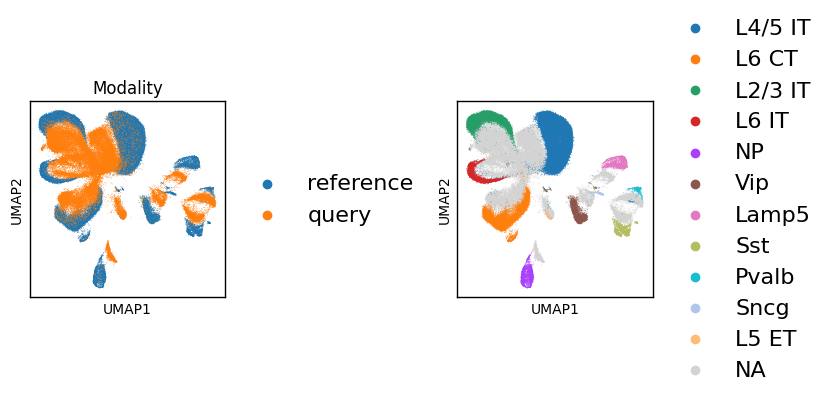

In [ ]:
counts = adata_gex.obs['cell_type'].value_counts()
celltype_order = counts.index.tolist()
adata.obs['cell_type'] = adata.obs['cell_type'].astype(
    pd.CategoricalDtype(categories=celltype_order, ordered=True)  # from adata_gex
)


sc.settings._vector_friendly = True

# Make sure the default edge isn’t white or hairline
mpl.rcParams['axes.edgecolor'] = 'black'
mpl.rcParams['axes.linewidth'] = 1.0

def force_border(ax):
    ax.set_axis_on()           # ensure axes are on
    ax.set_frame_on(True)      # ensure frame is drawn
    ax.patch.set_visible(True) # ensure background patch exists
    for side in ax.spines.values():
        side.set_visible(True)
        side.set_color('black')
        side.set_linewidth(1.0)

methods = ["X_pca_shared_aligned"]

ncols = 2 * len(methods)
fig, axes = plt.subplots(1, ncols, figsize=(4.2*ncols, 4.2), squeeze=False)
axes = axes[0]

for i, method in enumerate(methods):
    basis = f"X_umap_{method}"
    axL, axR = axes[2*i], axes[2*i+1]   

    sc.pl.embedding(
        adata, basis="umap", color="modality",
        frameon=True, ax=axL, show=False,
        legend_loc="right margin", legend_fontsize=16, title='Modality'
    )
    axL.set_box_aspect(1)
    axL.set_xlabel("UMAP1"); axL.set_ylabel("UMAP2")
    force_border(axL)    

    sc.pl.embedding(
        adata, basis="umap", color="cell_type", # "scBIOT_celltype", #"cell_type",
        frameon=True, ax=axR, show=False,
        legend_loc="right margin", legend_fontsize=16, title=""
    )
    axR.set_box_aspect(1)
    axR.set_xlabel("UMAP1"); axR.set_ylabel("UMAP2")
    force_border(axR)

plt.tight_layout()
# fig.savefig(f"{cwd}_batch_and_leiden_per_embedding.pdf", dpi=300, transparent=True)


In [ ]:
adata_ga

AnnData object with n_obs × n_vars = 54844 × 15185
    obs: 'domain', 'protocol', 'dataset', 'cell_type', 'batch', 'modality', 'pred_cell_type', 'pred_confidence'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'hvg', 'log1p', 'pca', '_ot_alignment', '_supbiot', 'pred_cell_type_colors'
    obsm: 'X_pca', 'X_supbiot'
    varm: 'PCs'

In [ ]:
fig, ax, counts_df, norm_df = scb.pl.plot_anndata_confusion(
    adata_ga, true_key="cell_type", pred_key="pred_cell_type",
    normalize="pred", annotate_mapping=True, return_data=True
)
plt.show()

AttributeError: 'DataFrame' object has no attribute 'str'